In [1]:
# IMPORT THE REQUIRED LIBRARIES
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# IMPORT MACHINE LEARNING MODULES
from sklearn import tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# READ THE SALARY PREDICTION DATASET
salary_data = pd.read_csv("C:/Users/Admin/Documents/arc_model_core/ml_docs/Datasets/salaries_records_expeneded.csv")


print(f":> DATASET SHAPE: {salary_data.shape}")
salary_data.head(10)

:> DATASET SHAPE: (3200, 15)


,Company,Job,Degree,Experience_Level,Years_Experience,Salary_more_than_100k,Salary_K,Employment_Type,Location,Remote_Status,Age,Performance_Rating,Bonus_Percentage,Education_Year,Gender
0,Snapchat,sales executive,bachelors,senior,12,1,126,full-time,USA,onsite,33,3.6,0.7,2018,Female
1,Airbnb,devops engineer,phd,lead,17,1,101,full-time,Canada,onsite,39,3.6,6.9,2018,Non-binary
2,Amazon,HR manager,bachelors,senior,7,0,86,contract,Singapore,onsite,34,2.8,9.2,2023,Non-binary
3,Twitter,devops engineer,phd,entry,1,1,120,full-time,Singapore,remote,24,3.5,11.3,2023,Female
4,IBM,devops engineer,phd,senior,12,0,44,part-time,Germany,onsite,34,4.3,1.6,2018,Non-binary
5,Pinterest,QA engineer,bachelors,mid,6,0,57,full-time,France,remote,27,4.8,5.7,2019,Female
6,Intel,ML engineer,master,mid,5,1,249,contract,Canada,onsite,31,3.5,5.5,2022,Prefer not to say
7,PayPal,data scientist,bachelors,mid,6,1,116,part-time,Canada,hybrid,32,4.0,11.7,2020,Male
8,Pinterest,network engineer,master,senior,8,1,216,full-time,Canada,onsite,28,4.7,6.6,2016,Female
9,Shopify,ML engineer,master,mid,4,1,238,full-time,Germany,onsite,24,3.3,0.5,2022,Non-binary


In [2]:
# CHECK FOR MISSING VALUES IN THE DATASET
print("=>> MISSING VALUES PER COLUMN >>")
salary_data.isnull().sum()

=>> MISSING VALUES PER COLUMN >>


Company                  0
Job                      0
Degree                   0
Experience_Level         0
Years_Experience         0
Salary_more_than_100k    0
Salary_K                 0
Employment_Type          0
Location                 0
Remote_Status            0
Age                      0
Performance_Rating       0
Bonus_Percentage         0
Education_Year           0
Gender                   0
dtype: int64

In [3]:
# DISPLAY DATASET INFORMATION (DATA TYPES, NON-NULL COUNTS, MEMORY USAGE)
salary_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Company                3200 non-null   str    
 1   Job                    3200 non-null   str    
 2   Degree                 3200 non-null   str    
 3   Experience_Level       3200 non-null   str    
 4   Years_Experience       3200 non-null   int64  
 5   Salary_more_than_100k  3200 non-null   int64  
 6   Salary_K               3200 non-null   int64  
 7   Employment_Type        3200 non-null   str    
 8   Location               3200 non-null   str    
 9   Remote_Status          3200 non-null   str    
 10  Age                    3200 non-null   int64  
 11  Performance_Rating     3200 non-null   float64
 12  Bonus_Percentage       3200 non-null   float64
 13  Education_Year         3200 non-null   int64  
 14  Gender                 3200 non-null   str    
dtypes: float64(2), 

In [4]:
# DISPLAY SUMMARY STATISTICS OF THE DATASET
salary_data.describe()

,Years_Experience,Salary_more_than_100k,Salary_K,Age,Performance_Rating,Bonus_Percentage,Education_Year
count,3200.00000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000
mean,7.89000,0.526563,124.417500,31.395937,3.758656,8.897469,2018.916250
std,6.00597,0.499372,62.819858,6.441973,0.723974,6.620515,4.816403
min,0.00000,0.000000,40.000000,21.000000,2.500000,0.000000,2000.000000
25%,2.00000,0.000000,70.000000,26.000000,3.100000,3.800000,2016.000000
50%,7.00000,1.000000,107.000000,30.000000,3.800000,7.300000,2020.000000
75%,12.00000,1.000000,178.000000,36.000000,4.400000,12.500000,2023.000000
max,20.00000,1.000000,250.000000,47.000000,5.000000,25.000000,2024.000000


In [5]:
# DISPLAY VALUE COUNTS FOR THE TARGET VARIABLE
print("=>> TARGET VARIABLE DISTRIBUTION >>")
salary_data['Salary_more_than_100k'].value_counts()

=>> TARGET VARIABLE DISTRIBUTION >>


Salary_more_than_100k
1    1685
0    1515
Name: count, dtype: int64

In [6]:
# CALCULATE AND DISPLAY PERCENTAGE OF EMPLOYEES WITH SALARY > 100k
print(f":> PERCENTAGE WITH SALARY >100k: {salary_data['Salary_more_than_100k'].mean() * 100:.1f}%")

:> PERCENTAGE WITH SALARY >100k: 52.7%


In [7]:
# DISPLAY DATASET INFORMATION (VERIFICATION AFTER CLEANING)
salary_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Company                3200 non-null   str    
 1   Job                    3200 non-null   str    
 2   Degree                 3200 non-null   str    
 3   Experience_Level       3200 non-null   str    
 4   Years_Experience       3200 non-null   int64  
 5   Salary_more_than_100k  3200 non-null   int64  
 6   Salary_K               3200 non-null   int64  
 7   Employment_Type        3200 non-null   str    
 8   Location               3200 non-null   str    
 9   Remote_Status          3200 non-null   str    
 10  Age                    3200 non-null   int64  
 11  Performance_Rating     3200 non-null   float64
 12  Bonus_Percentage       3200 non-null   float64
 13  Education_Year         3200 non-null   int64  
 14  Gender                 3200 non-null   str    
dtypes: float64(2), 

In [8]:
# DEFINE FEATURE COLUMNS FOR MODEL TRAINING
features_cols = [
    "Company",
    "Job",
    "Degree",
    "Experience_Level",
    "Years_Experience",
    "Employment_Type",
    "Location",
    "Remote_Status",
    "Age",
    "Performance_Rating",
    "Gender"
]

# SEPARATE FEATURES (X) AND TARGET VARIABLE (y)
X = salary_data[features_cols]
y = salary_data['Salary_more_than_100k']

# DISPLAY THE SHAPE OF FEATURES AND TARGET
print(f":> FEATURES SHAPE (X): {X.shape}")
print(f":> TARGET SHAPE (y): {y.shape}")

:> FEATURES SHAPE (X): (3200, 11)
:> TARGET SHAPE (y): (3200,)


In [9]:
# INITIALIZE DICTIONARY TO STORE LABEL ENCODERS FOR EACH COLUMN
label_encoders = {}


# APPLY LABEL ENCODING TO ALL CATEGORICAL COLUMNS
for col in X.select_dtypes(include='object').columns:
        encoder = LabelEncoder()
        X[col] = encoder.fit_transform(X[col].astype(str))
        label_encoders[col] = encoder
        print(f":> ENCODED {col}: {dict(zip(encoder.classes_, range(len(encoder.classes_))))}")

:> ENCODED Company: {'AMD': 0, 'Adobe': 1, 'Airbnb': 2, 'Amazon': 3, 'Apple': 4, 'Atlassian': 5, 'Dropbox': 6, 'Google': 7, 'IBM': 8, 'Intel': 9, 'LinkedIn': 10, 'Meta': 11, 'Microsoft': 12, 'Netflix': 13, 'Nvidia': 14, 'Oracle': 15, 'PayPal': 16, 'Pinterest': 17, 'Qualcomm': 18, 'Salesforce': 19, 'ServiceNow': 20, 'Shopify': 21, 'Snapchat': 22, 'Spotify': 23, 'Square': 24, 'Stripe': 25, 'Tesla': 26, 'Twitter': 27, 'Uber': 28, 'Zoom': 29}
:> ENCODED Job: {'AI researcher': 0, 'HR manager': 1, 'IT support': 2, 'ML engineer': 3, 'QA engineer': 4, 'UX designer': 5, 'backend developer': 6, 'business manager': 7, 'cloud architect': 8, 'consultant': 9, 'data scientist': 10, 'database admin': 11, 'devops engineer': 12, 'financial analyst': 13, 'frontend developer': 14, 'fullstack developer': 15, 'game developer': 16, 'marketing manager': 17, 'mobile developer': 18, 'network engineer': 19, 'operations manager': 20, 'product manager': 21, 'project manager': 22, 'sales executive': 23, 'security a

C:\Users\Admin\AppData\Local\Temp\ipykernel_14912\262713607.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include='object').columns:


In [10]:
# PREVIEW THE ENCODED FEATURES
X.head(10)

,Company,Job,Degree,Experience_Level,Years_Experience,Employment_Type,Location,Remote_Status,Age,Performance_Rating,Gender
0,22,23,0,3,12,1,7,1,33,3.6,0
1,2,12,2,1,17,1,1,1,39,3.6,2
2,3,1,0,3,7,0,5,1,34,2.8,2
3,27,12,2,0,1,1,5,2,24,3.5,0
4,8,12,2,3,12,2,3,1,34,4.3,2
5,17,4,0,2,6,1,2,2,27,4.8,0
6,9,3,1,2,5,0,1,1,31,3.5,3
7,16,10,0,2,6,2,1,0,32,4.0,1
8,17,19,1,3,8,1,1,1,28,4.7,0
9,21,3,1,2,4,1,3,1,24,3.3,2


In [11]:
# VERIFY DATA TYPES AFTER ENCODING
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Company             3200 non-null   int64  
 1   Job                 3200 non-null   int64  
 2   Degree              3200 non-null   int64  
 3   Experience_Level    3200 non-null   int64  
 4   Years_Experience    3200 non-null   int64  
 5   Employment_Type     3200 non-null   int64  
 6   Location            3200 non-null   int64  
 7   Remote_Status       3200 non-null   int64  
 8   Age                 3200 non-null   int64  
 9   Performance_Rating  3200 non-null   float64
 10  Gender              3200 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 275.1 KB


In [12]:
# SPLIT THE DATA INTO TRAINING AND TESTING SETS (80% TRAIN, 20% TEST)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y      # PRESERVE CLASS DISTRIBUTION
)

# DISPLAY TRAINING AND TEST SET SIZES
print(f":> TRAINING SET SIZE: {len(X_train)}")
print(f":> TEST SET SIZE: {len(X_test)}")


# DISPLAY CLASS DISTRIBUTION IN TRAINING SET
print("\n\n=>> TRAINING SET CLASS DISTRIBUTION >>")
print("=" * 50)
print(y_train.value_counts(normalize=True))

# DISPLAY CLASS DISTRIBUTION IN TEST SET
print("\n=>> TEST SET CLASS DISTRIBUTION >>")
print("=" * 50)
print(y_test.value_counts(normalize=True))

:> TRAINING SET SIZE: 2560
:> TEST SET SIZE: 640


=>> TRAINING SET CLASS DISTRIBUTION >>
Salary_more_than_100k
1    0.526563
0    0.473438
Name: proportion, dtype: float64

=>> TEST SET CLASS DISTRIBUTION >>
Salary_more_than_100k
1    0.526563
0    0.473438
Name: proportion, dtype: float64


In [13]:
decision_tree_model = tree.DecisionTreeClassifier(
    max_depth=10,               # MAXIMUM DEPTH OF THE TREE
    min_samples_split=10,       # MINIMUM SAMPLES REQUIRED TO SPLIT A NODE
    min_samples_leaf=5,         # MINIMUM SAMPLES REQUIRED AT A LEAF NODE
    random_state=42,            # REPRODUCIBILITY SEED
    criterion="gini"            # SPLIT CRITERION (GINI IMPURITY)
)

# TRAIN THE DECISION TREE MODEL
decision_tree_model.fit(X_train, y_train)
print(">> MODEL TRAINING COMPLETED SUCCESSFULLY.. ✅")

>> MODEL TRAINING COMPLETED SUCCESSFULLY.. ✅


In [14]:
# MAKE PREDICTIONS ON TRAINING AND TEST SETS
y_train_predicted = decision_tree_model.predict(X_train)
y_test_predicted = decision_tree_model.predict(X_test)

# CALCULATE ACCURACY SCORES
train_accuracy = accuracy_score(y_train, y_train_predicted)
test_accuracy = accuracy_score(y_test, y_test_predicted)

# DISPLAY ACCURACY METRICS
print("=>> MODEL ACCURACY METRICS >>")
print(f":> TRAIN ACCURACY: {train_accuracy:.4f} ({train_accuracy * 100:.2f}%)")
print(f":> TEST ACCURACY: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print(f":> OVERFITTING GAPs: {(train_accuracy - test_accuracy) * 100:.2f}%")


print("\n" + "=" * 50)

# DISPLAY CLASSIFICATION REPORT FOR TEST SET
print("=>> CLASSIFICATION REPORT (TEST SET) >>")
print(classification_report(y_test, y_test_predicted, target_names=['<=100k', '>100k']))


print("\n" + "=" * 50)

# GENERATE AND DISPLAY CONFUSION MATRIX
print("=>> CONFUSION METRIX >>")
confusion_mat = confusion_matrix(y_test, y_test_predicted)
print(confusion_mat)


print("\n" + "=" * 50)

# EXTRACT AND DISPLAY CONFUSION MATRIX COMPONENTS
tn, fp, fn, tp = confusion_mat.ravel()
print(f"=>> CONFUSION MATRIX BREAKDOWN >>")
print(f":> TRUE NEGATIVE (Correctly predicted <=100k): {tn}")
print(f":> FALSE POSITIVE (Incorrectly predicted >100k): {fp}")
print(f":> FALSE NEGATIVE (Incorrectly predicted <=100k): {fn}")
print(f":> TRUE POSITIVE (Correctly predicted >100k): {tp}")

=>> MODEL ACCURACY METRICS >>
:> TRAIN ACCURACY: 0.7930 (79.30%)
:> TEST ACCURACY: 0.6250 (62.50%)
:> OVERFITTING GAPs: 16.80%

=>> CLASSIFICATION REPORT (TEST SET) >>
              precision    recall  f1-score   support

      <=100k       0.61      0.57      0.59       303
       >100k       0.64      0.67      0.65       337

    accuracy                           0.62       640
   macro avg       0.62      0.62      0.62       640
weighted avg       0.62      0.62      0.62       640


=>> CONFUSION METRIX >>
[[173 130]
 [110 227]]

=>> CONFUSION MATRIX BREAKDOWN >>
:> TRUE NEGATIVE (Correctly predicted <=100k): 173
:> FALSE POSITIVE (Incorrectly predicted >100k): 130
:> FALSE NEGATIVE (Incorrectly predicted <=100k): 110
:> TRUE POSITIVE (Correctly predicted >100k): 227


In [15]:
# CALCULATE AND DISPLAY FEATURE IMPORTANCE
feature_importance = pd.DataFrame(
    {"Feature": features_cols, "Importance": decision_tree_model.feature_importances_}
).sort_values("Importance", ascending=False)

print("=>> FEATURE IMPORTANCE RANKING >>")
print(feature_importance)

=>> FEATURE IMPORTANCE RANKING >>
               Feature  Importance
5      Employment_Type    0.193192
8                  Age    0.155163
1                  Job    0.152717
0              Company    0.131745
9   Performance_Rating    0.092327
4     Years_Experience    0.075361
6             Location    0.062475
2               Degree    0.061406
10              Gender    0.041727
3     Experience_Level    0.018865
7        Remote_Status    0.015022


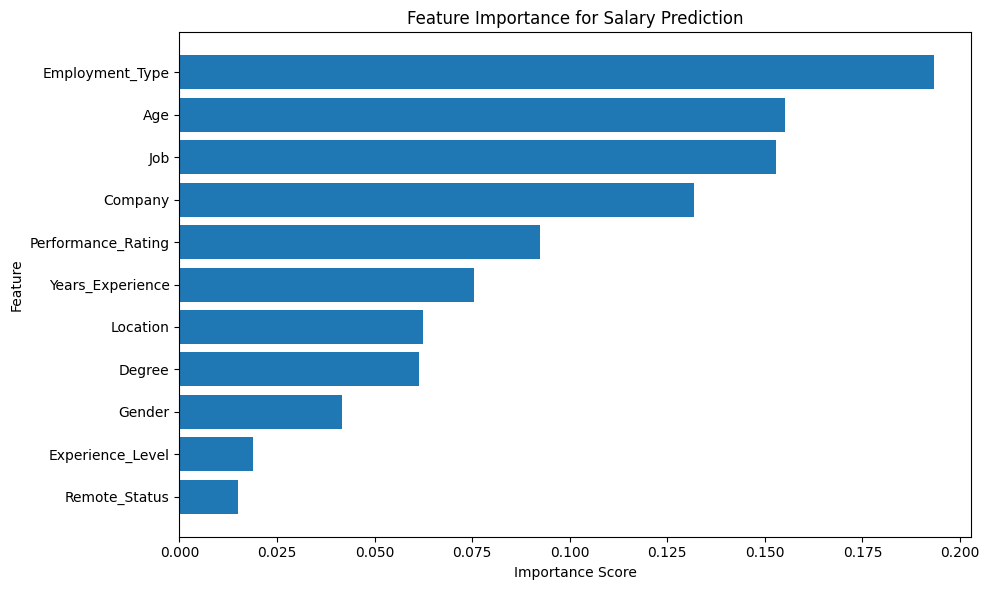

In [16]:
# VISUALIZE FEATURE IMPORTANCE
plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance for Salary Prediction")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

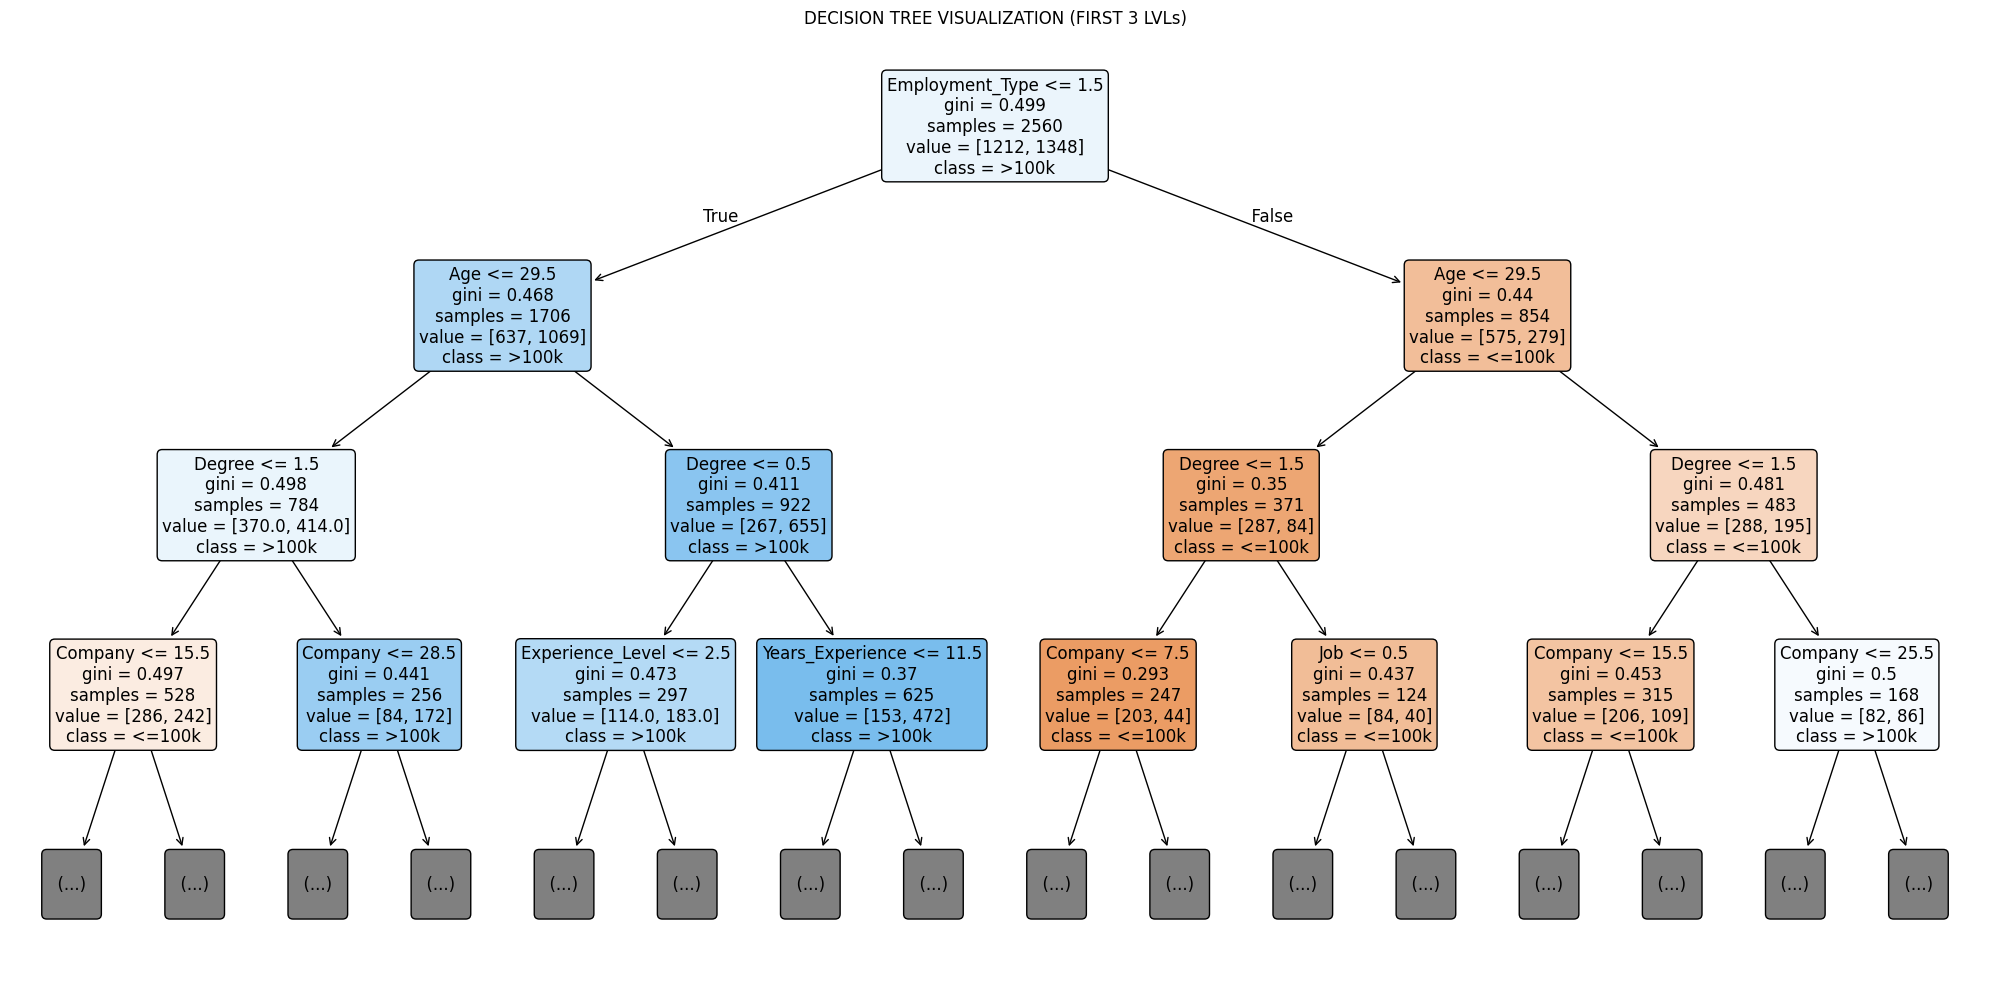

In [17]:
# VISUALIZE THE DECISION TREE (FIRST 3 LEVELS)
plt.figure(figsize=(20,10))
tree.plot_tree(
    decision_tree_model,
    max_depth=3,                # ONLY SHOW FIRST 3 LEVELS FOR READABILITY
    feature_names=features_cols,
    class_names=['<=100k', '>100k'],
    filled=True,                # COLOR NODES BY CLASS
    rounded=True,               # ROUNDED CORNERS FOR NODES
    fontsize=12
)

plt.title("DECISION TREE VISUALIZATION (FIRST 3 LVLs)")
plt.tight_layout()
plt.show()

In [18]:
# FUNCTION TO PREDICT SALARY FOR NEW DATA
def PREDICT_SALARY(
        company,
        job,
        degree,
        exp_lvl,
        year_exp,
        employment_type,
        location,
        remote_sts,
        age,
        perfo_rat,
        gender
):

    """
    Predict salary category (>100k or <=100k) based on input features.

    Args:
        company (str): Company name
        job (str): Job title
        degree (str): Educational qualification
        exp_lvl (str): Experience level (entry/mid/senior)
        year_exp (int): Years of experience
        employment_type (str): Full-time/Part-time/Contract
        location (str): Location (USA/India/UK etc.)
        remote_sts (str): Remote/Onsite/Hybrid
        age (int): Age of employee
        perfo_rat (float): Performance rating (1.0-5.0)
        gender (str): Gender

    Returns:
        tuple: (prediction, probability)
    """

    # CREATE DATAFRAME WITH INPUT FEATURES
    new_data = pd.DataFrame(
        [
            [
                company,
                job,
                degree,
                exp_lvl,
                year_exp,
                employment_type,
                location,
                remote_sts,
                age,
                perfo_rat,
                gender,
            ]
        ],
        columns=features_cols
    )

    # APPLY LABEL ENCODING USING STORED ENCODERS
    for col in label_encoders:
        le = label_encoders[col]

        value = str(new_data[col].iloc[0])

        if value in le.classes_:
            new_data[col] = le.transform([value])
        else:
            raise ValueError(f"WARNING: Unkown Values: '{value}' for column '{col}'")
            # new_data[col] = le.transform([le.classes_[0]])[0]

    # MAKE PREDICTION AND GET PROBABILITIES
    prediction = decision_tree_model.predict(new_data)[0]
    probability = decision_tree_model.predict_proba(new_data)[0]

    # INTERPRET RESULTS
    result = ">100k" if prediction == 1 else "<=100k"
    confidence = max(probability) * 100

    # DISPLAY INPUT FEATURES
    print(f">> INPUT FEATURES:")
    print("-" * 18)
    print(f"  Company: '{company}'")
    print(f"  Job: '{job}'")
    print(f"  Degree: '{degree}'")
    print(f"  Experience Level: '{exp_lvl}'")
    print(f"  Years Experience: '{year_exp}'")
    print(f"  Employment Type: '{employment_type}'")
    print(f"  Location: '{location}'")
    print(f"  Remote Status: '{remote_sts}'")
    print(f"  Age: '{age}'")
    print(f"  Performance Rating: '{perfo_rat}'")
    print(f"  Gender: '{gender}'")

    # DISPLAY PREDICTION RESULTS
    print(f"\n{'=' * 50}")
    print(f":> PREDICTION: Salary {result}")
    print(f":> CONFIDENCE: {confidence:.2f}%")
    print(
        f":> PROBABILITY DISTRIBUTION: <=100k: {probability[0]:.2%}, >100k: {probability[1]:.2%}"
    )
    print(f"{'=' * 50}")

    return prediction, probability


# EXAMPLE 1: Experienced programmer at Google
print("=>> EXAMPLE 1: EXPERIENCED PROGRAMMER AT GOOGLE >>")
print("=" * 50)
PREDICT_SALARY(
    company="Google",
    job="software engineer",
    degree="master",
    exp_lvl="senior",
    year_exp=8,
    employment_type="full-time",
    location="USA",
    remote_sts="remote",
    age=32,
    perfo_rat=4.5,
    gender="Male",
)

# EXAMPLE 2: Entry-level sales executive
print("\n\n\n=>> EXAMPLE 2: ENTRY-LVL SALES EXECUTIVE >>")
print("=" * 50)
PREDICT_SALARY(
    company="Nvidia",
    job="sales executive",
    degree="bachelors",
    exp_lvl="entry",
    year_exp=1,
    employment_type="full-time",
    location="India",
    remote_sts="onsite",
    age=23,
    perfo_rat=3.0,
    gender="Female",
)

# EXAMPLE 3: Mid-level manager with PhD
print("\n\n\n=>> EXAMPLE 3: MID-LEVEL MANAGER WITH PhD >>")
print("=" * 50)
PREDICT_SALARY(
    company="Microsoft",
    job="business manager",
    degree="phd",
    exp_lvl="mid",
    year_exp=5,
    employment_type="full-time",
    location="USA",
    remote_sts="hybrid",
    age=30,
    perfo_rat=4.2,
    gender="Non-binary",
)

=>> EXAMPLE 1: EXPERIENCED PROGRAMMER AT GOOGLE >>
>> INPUT FEATURES:
------------------
  Company: 'Google'
  Job: 'software engineer'
  Degree: 'master'
  Experience Level: 'senior'
  Years Experience: '8'
  Employment Type: 'full-time'
  Location: 'USA'
  Remote Status: 'remote'
  Age: '32'
  Performance Rating: '4.5'
  Gender: 'Male'

:> PREDICTION: Salary >100k
:> CONFIDENCE: 100.00%
:> PROBABILITY DISTRIBUTION: <=100k: 0.00%, >100k: 100.00%



=>> EXAMPLE 2: ENTRY-LVL SALES EXECUTIVE >>
>> INPUT FEATURES:
------------------
  Company: 'Nvidia'
  Job: 'sales executive'
  Degree: 'bachelors'
  Experience Level: 'entry'
  Years Experience: '1'
  Employment Type: 'full-time'
  Location: 'India'
  Remote Status: 'onsite'
  Age: '23'
  Performance Rating: '3.0'
  Gender: 'Female'

:> PREDICTION: Salary >100k
:> CONFIDENCE: 71.43%
:> PROBABILITY DISTRIBUTION: <=100k: 28.57%, >100k: 71.43%



=>> EXAMPLE 3: MID-LEVEL MANAGER WITH PhD >>
>> INPUT FEATURES:
------------------
  Company: 'M

(np.int64(1), array([0.375, 0.625]))

In [19]:
# PERFORM HYPERPARAMETER TUNING USING GRID SEARCH
param_grid = {
    'max_depth': [5,8,10,12,15, None],
    'min_samples_split': [5,10,20,50],
    'min_samples_leaf': [2,5,10,20],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    tree.DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,               # 5-FOLD CROSS-VALIDATION
    scoring='accuracy',
    n_jobs=1
)

grid_search.fit(X_train, y_train)

# DISPLAY BEST PARAMETERS FOUND
print("=>> BEST HYPERPARAMETERS FOUND >>")
for param, value in grid_search.best_params_.items():
    print(f":> {param}: {value}")

print("\n" + "-" * 35)
print(f":> BEST CROSS-VALIDATION SCORE: {grid_search.best_score_:.4f}")

# EVALUATE THE BEST MODEL ON TEST SET
best_model = grid_search.best_estimator_
y_best_pred = best_model.predict(X_test)
best_accuracy = accuracy_score(y_test, y_best_pred)
print(f":> BEST MODEL TEST ACCURACY: {best_accuracy * 100:.4f}")

=>> BEST HYPERPARAMETERS FOUND >>
:> criterion: entropy
:> max_depth: 5
:> min_samples_leaf: 20
:> min_samples_split: 50

-----------------------------------
:> BEST CROSS-VALIDATION SCORE: 0.6543
:> BEST MODEL TEST ACCURACY: 66.8750


In [21]:
# PERFORM CROSS-VALIDATION ON THE ORIGINAL MODEL
cv_score = cross_val_score(decision_tree_model, X, y, cv=5)

print(f"=>> CROSS-VALIDATION SCORES (5-FOLD) >>")
print("=" * 50)
print(f":> Individual Scores: {cv_score}")
print(f":> MEAN CV SCORE: {cv_score.mean():.4f} (+/- {cv_score.std() * 2:.4f})")

=>> CROSS-VALIDATION SCORES (5-FOLD) >>
:> Individual Scores: [0.6125    0.6       0.5765625 0.5984375 0.575    ]
:> MEAN CV SCORE: 0.5925 (+/- 0.0290)
